In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 🔹 1. Carregamento Base Consolidada

In [157]:
# Carregar base
df = pd.read_csv("../data/raw/dataset_concatenado.csv")

In [158]:
# informações de tamanho do dataset
df.shape

(3030, 56)

In [159]:
#Visualizar das colunas
df.columns

Index(['RA', 'FASE', 'TURMA', 'NOME_ALUNO', 'ANO_NASC', 'IDADE', 'GENERO',
       'ANO_INGRESSO', 'INSTITUICAO_ENSINO', 'PEDRA_2020', 'PEDRA_2021',
       'PEDRA_2022', 'INDE_2022', 'GC', 'CF', 'CT', 'N_AVALIADOR',
       'AVALIADOR_1', 'REC_EQUIPE_1', 'AVALIADOR_2', 'REC_EQUIPE_2',
       'AVALIADOR_3', 'REC_EQUIPE_3', 'AVALIADOR_4', 'REC_EQUIPE_4', 'IAA',
       'IEG', 'IPS', 'REC_PSICO', 'IDA', 'NOTA_MATEM', 'NOTA_PORT',
       'NOTA_INGL', 'INDC_BOLSA', 'ATING_PV', 'IND_PV', 'IAN', 'NIVEL_IDEAL',
       'DEFASAGEM', 'DESTAQUE_IEG', 'DESTAQUE_IDA', 'DESTAQUE_IPV', 'ANO',
       'INDE_2023', 'PEDRA_2023', 'DT_NASC', 'CG', 'IPP', 'DESTAQUE_IPV.1',
       'INDE_2024', 'PEDRA_2024', 'AVALIADOR_5', 'AVALIADOR_6', 'ESCOLA',
       'ATIVO/INATIVO', 'ATIVO/INATIVO.1'],
      dtype='str')

In [160]:
# Verificar tipos de dados
print(df.dtypes)

RA                        str
FASE                      str
TURMA                     str
NOME_ALUNO                str
ANO_NASC              float64
IDADE                     str
GENERO                    str
ANO_INGRESSO            int64
INSTITUICAO_ENSINO        str
PEDRA_2020                str
PEDRA_2021                str
PEDRA_2022                str
INDE_2022             float64
GC                    float64
CF                    float64
CT                    float64
N_AVALIADOR           float64
AVALIADOR_1               str
REC_EQUIPE_1              str
AVALIADOR_2               str
REC_EQUIPE_2              str
AVALIADOR_3               str
REC_EQUIPE_3              str
AVALIADOR_4               str
REC_EQUIPE_4              str
IAA                   float64
IEG                   float64
IPS                   float64
REC_PSICO                 str
IDA                   float64
NOTA_MATEM            float64
NOTA_PORT             float64
NOTA_INGL             float64
INDC_BOLSA

### 🔹 2 - Criação da Target 
**Definição sugerida (binária):**  
- `POSSUI_DEFASAGEM = 1` quando `DEFASAGEM < 0`  
- `POSSUI_DEFASAGEM = 0` quando `DEFASAGEM == 0`

In [161]:
# Criar coluna de defasagem (target)
if "DEFASAGEM" in df.columns:
    df["POSSUI_DEFASAGEM"] = (df["DEFASAGEM"] < 0).astype(int)
else:
    raise ValueError("Coluna DEFASAGEM não encontrada. Ajuste o nome da coluna.")

In [162]:
# Distribuição do target
display(df["POSSUI_DEFASAGEM"].value_counts(normalize=True))

POSSUI_DEFASAGEM
1    0.556766
0    0.443234
Name: proportion, dtype: float64

### 🔹3 -  Verificação de Presença de Nulos

In [163]:
percentual_nulos = (df.isnull().mean() * 100).sort_values(ascending=False)

pd.DataFrame({ "Qtd_Nulos": df.isnull().sum(),"%_Nulos": percentual_nulos}).query("Qtd_Nulos > 0")

,Qtd_Nulos,%_Nulos
ANO_NASC,2170,71.617162
ATING_PV,2170,71.617162
ATIVO/INATIVO,1874,61.848185
ATIVO/INATIVO.1,1874,61.848185
AVALIADOR_1,203,6.699670
AVALIADOR_2,203,6.699670
AVALIADOR_3,996,32.871287
AVALIADOR_4,1979,65.313531
AVALIADOR_5,2882,95.115512
AVALIADOR_6,3024,99.801980


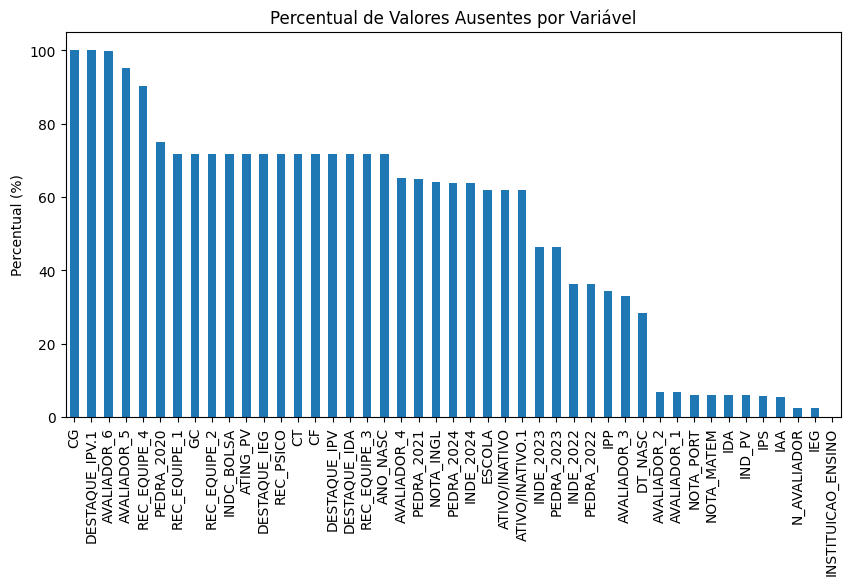

In [164]:
percentual_nulos[percentual_nulos > 0].plot(kind="bar", figsize=(10,5))
plt.title("Percentual de Valores Ausentes por Variável")
plt.ylabel("Percentual (%)")
plt.show()

Atráves da tabela e do gráfico é possivel verificar que algumas variáveis apresentam um percentual extremamente elevado de valores nulos (acima de 95%), como CG, DESTAQUE_IPV.1 e AVALIADOR_6, além disso, há um grupo relevante de variáveis com mais de 70% de dados ausentes, grande parte desses dados são de informações de recomendações de equipe.

Por outro lado, identificou-se um conjunto consistente de variáveis com baixo percentual de valores ausentes (inferior a 10%), como IEG, IAA, IPS, IDA, NOTA_MATEM, NOTA_PORT e IND_PV. Essas variáveis apresentam maior completude e tendem a ser mais confiáveis para compor a base principal de modelagem.

### 🔹4 -  Correção de tipos

In [165]:
tipos = pd.DataFrame({"coluna": df.columns,"tipo": df.dtypes.values})
tipos

,coluna,tipo
0,RA,str
1,FASE,str
2,TURMA,str
3,NOME_ALUNO,str
4,ANO_NASC,float64
5,IDADE,str
6,GENERO,str
7,ANO_INGRESSO,int64
8,INSTITUICAO_ENSINO,str
9,PEDRA_2020,str


Foi identificado que a coluna IDADE está formatada como string. Considerando que se trata de uma variável quantitativa, será aplicada conversão para tipo numérico.

In [166]:
df["IDADE"] = pd.to_numeric(df["IDADE"], errors="coerce")

### 🔹 5 - Encoding

In [167]:
#verificar valores únicos da variável FASE
df["FASE"].unique()

<StringArray>
[     '7',      '6',      '5',      '4',      '3',      '2',      '1',
      '0',   'ALFA', 'FASE 1', 'FASE 2', 'FASE 3', 'FASE 4', 'FASE 5',
 'FASE 6', 'FASE 7', 'FASE 8',     '1A',     '1B',     '1C',     '1D',
     '1E',     '1G',     '1H',     '1J',     '1K',     '1L',     '1M',
     '1N',     '1P',     '1R',     '2A',     '2B',     '2C',     '2D',
     '2G',     '2H',     '2I',     '2K',     '2L',     '2M',     '2N',
     '2P',     '2R',     '2U',     '3A',     '3B',     '3C',     '3D',
     '3F',     '3G',     '3H',     '3I',     '3K',     '3L',     '3M',
     '3N',     '3P',     '3R',     '3U',     '4A',     '4B',     '4C',
     '4F',     '4H',     '4L',     '4M',     '4N',     '4R',     '5A',
     '5B',     '5C',     '5D',     '5F',     '5G',     '5L',     '5M',
     '5N',     '6A',     '6L',     '7A',     '7E',     '8A',     '8B',
     '8D',     '8E',     '8F',      '9']
Length: 88, dtype: str

In [168]:
# Substituir "ALFA" por 0 e extrair apenas os números, convertendo para int
df["FASE"] = (
    df["FASE"]
    .replace("ALFA", "0")
    .astype(str)
    .str.extract("(\d+)")
    .astype(int)
)

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Joyce\AppData\Local\Temp\ipykernel_19180\4166135604.py:6: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")


In [169]:
#verificar valores únicos da variável GENERO
df["GENERO"].unique()

<StringArray>
['Menina', 'Menino', 'Feminino', 'Masculino']
Length: 4, dtype: str

In [170]:
# Substituir "MASCULINO" & "MENINO"  por 0 e "FEMININO" & "MENINA" por 1, convertendo para int
df["GENERO"] = df["GENERO"].astype(str).str.strip().str.upper()
df["GENERO"] = df["GENERO"].replace({"MASCULINO": 0, "MENINO": 0,"FEMININO": 1,"MENINA": 1}).astype("Int64")

In [171]:
#verificar valores únicos da variável instituição de ensino
df["INSTITUICAO_ENSINO"].unique()

<StringArray>
[                           'Escola Pública',
                              'Rede Decisão',
                              'Escola JP II',
                                   'Pública',
                                   'Privada',
      'Privada - Programa de Apadrinhamento',
      'Privada - Programa de apadrinhamento',
                          'Concluiu o 3º EM',
                  'Nenhuma das opções acima',
         'Privada *Parcerias com Bolsa 100%',
 'Privada - Pagamento por *Empresa Parceira',
                                         nan,
       'Bolsista Universitário *Formado (a)']
Length: 13, dtype: str

In [172]:
# Padroniza texto para evitar erro de maiúscula/minúscula
df["INSTITUICAO_ENSINO"] = df["INSTITUICAO_ENSINO"].str.strip()

map_instituicao = {
    # 1 - Escola Pública
    "Escola Pública": 1,
    "Pública": 1,

    # 2 - Escola Privada
    "Rede Decisão": 2,
    "Escola JP II": 2,
    "Privada": 2,

    # 3 - Programa de Apadrinhamento
    "Privada - Programa de Apadrinhamento": 3,
    "Privada - Programa de apadrinhamento": 3,

    # 4 - Parceria Bolsa 100%
    "Privada *Parcerias com Bolsa 100%": 4,

    # 5 - Empresa Parceira
    "Privada - Pagamento por *Empresa Parceira": 5,

    # 6 - Concluinte
    "Concluiu o 3º EM": 6,

    # 7 - Bolsista Universitário
    "Bolsista Universitário *Formado (a)": 7,

    # 8 - Nenhuma das opções
    "Nenhuma das opções acima": 8
}

df["INSTITUICAO_ENSINO"] = (
    df["INSTITUICAO_ENSINO"]
    .map(map_instituicao)
)

# Preencher nulos como 8
df["INSTITUICAO_ENSINO"] = df["INSTITUICAO_ENSINO"].fillna(8)

In [173]:
df

,RA,FASE,TURMA,NOME_ALUNO,ANO_NASC,IDADE,GENERO,ANO_INGRESSO,INSTITUICAO_ENSINO,PEDRA_2020,...,IPP,DESTAQUE_IPV.1,INDE_2024,PEDRA_2024,AVALIADOR_5,AVALIADOR_6,ESCOLA,ATIVO/INATIVO,ATIVO/INATIVO.1,POSSUI_DEFASAGEM
0,RA-1,7,A,Aluno-1,2003.0,19.0,1,2016,1.0,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,RA-2,7,A,Aluno-2,2005.0,17.0,1,2017,2.0,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,RA-3,7,A,Aluno-3,2005.0,17.0,1,2016,2.0,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,RA-4,7,A,Aluno-4,2005.0,17.0,0,2017,2.0,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,RA-5,7,A,Aluno-5,2005.0,17.0,1,2016,2.0,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3025,RA-1658,9,9,Aluno-1658,NaN,21.0,0,2021,2.0,NaN,...,NaN,NaN,INCLUIR,INCLUIR,NaN,NaN,Faculdade (FIAP),Cursando,Cursando,0
3026,RA-1659,9,9,Aluno-1659,NaN,21.0,0,2021,7.0,NaN,...,NaN,NaN,INCLUIR,INCLUIR,NaN,NaN,Bolsista Universitário *Formado (a),Cursando,Cursando,0
3027,RA-1252,9,9,Aluno-1252,NaN,22.0,1,2021,2.0,NaN,...,NaN,NaN,INCLUIR,INCLUIR,NaN,NaN,Faculdade (FIAP),Cursando,Cursando,0
3028,RA-1660,9,9,Aluno-1660,NaN,24.0,1,2021,7.0,NaN,...,NaN,NaN,INCLUIR,INCLUIR,NaN,NaN,Bolsista Universitário *Formado (a),Cursando,Cursando,0


### 🔹 6 - Filtros

Observou-se que os indivíduos classificados na Fase 8 e 9 (+ Universitários) não possuem registros de notas ou indicadores de defasagem, em razão das regras de negócio aplicáveis a essa etapa. Dessa forma, a ausência dessas informações para esse público não se caracteriza como dado faltante aleatório, mas sim como uma condição inerente ao processo avaliativo aplicado a essa fase. Consiserando essas premissas as análises que envolvam desempenho acadêmico ou defasagem deverão excluir esse grupo ou tratá-lo de forma segmentada, a fim de evitar vieses interpretativos.

In [174]:
#aplicação de filtro desconsiderando a fase 9
df = df[~df["FASE"].isin([8, 9])]

In [175]:
df.shape

(2865, 57)

A nova base passa a ter 2992 observações

### 🔹 7 - Seleção Features

In [176]:
df_modelo = df[['ANO','FASE','IDADE','GENERO','ANO_INGRESSO','INSTITUICAO_ENSINO',
                'INDE_2022','INDE_2023','INDE_2024','IAA','IEG','IPS','IDA','IND_PV',
                'IAN','IPP','NOTA_MATEM','NOTA_PORT','NOTA_INGL','POSSUI_DEFASAGEM']]

In [177]:
df_modelo

,ANO,FASE,IDADE,GENERO,ANO_INGRESSO,INSTITUICAO_ENSINO,INDE_2022,INDE_2023,INDE_2024,IAA,IEG,IPS,IDA,IND_PV,IAN,IPP,NOTA_MATEM,NOTA_PORT,NOTA_INGL,POSSUI_DEFASAGEM
0,2022,7,19.0,1,2016,1.0,5.783000,NaN,NaN,8.300,4.100000,5.6000,4.000000,7.278,5.0,NaN,2.70,3.5,6.0,1
1,2022,7,17.0,1,2017,2.0,7.055000,NaN,NaN,8.800,5.200000,6.3000,6.800000,6.778,10.0,NaN,6.30,4.5,9.7,0
2,2022,7,17.0,1,2016,2.0,6.591000,NaN,NaN,0.000,7.900000,5.6000,5.600000,7.556,10.0,NaN,5.80,4.0,6.9,0
3,2022,7,17.0,0,2017,2.0,5.951000,NaN,NaN,8.800,4.500000,5.6000,5.000000,5.278,10.0,NaN,2.80,3.5,8.7,0
4,2022,7,17.0,1,2016,2.0,7.427000,NaN,NaN,7.900,8.600000,5.6000,5.200000,7.389,10.0,NaN,7.00,2.9,5.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,2024,7,15.0,0,2022,3.0,8.121970,8.493058,7.9319666667333335,8.751,9.737667,6.2600,6.166667,7.500,10.0,7.5,6.00,6.5,6.0,0
2924,2024,7,18.0,0,2021,4.0,7.566015,NaN,7.611233333266666,6.667,9.704333,6.5700,5.483333,7.500,10.0,7.5,6.35,6.3,3.8,0
2925,2024,7,15.0,0,2021,3.0,8.638474,7.794358,7.449366666666667,10.002,9.920000,6.8850,2.633333,7.500,10.0,7.5,0.00,0.0,7.9,0
2926,2024,7,16.0,0,2021,4.0,8.253050,8.105583,8.243183333333334,8.334,9.246000,6.5725,8.266667,7.500,10.0,7.5,8.20,7.8,8.8,0


In [178]:
p_nulos2 = (df_modelo.isnull().mean() * 100).sort_values(ascending=False)

In [179]:
df_modelo.info()

(df_modelo.isna().mean() * 100).sort_values(ascending=False)

<class 'pandas.DataFrame'>
Index: 2865 entries, 0 to 2927
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ANO                 2865 non-null   int64  
 1   FASE                2865 non-null   int64  
 2   IDADE               2493 non-null   float64
 3   GENERO              2865 non-null   Int64  
 4   ANO_INGRESSO        2865 non-null   int64  
 5   INSTITUICAO_ENSINO  2865 non-null   float64
 6   INDE_2022           1886 non-null   float64
 7   INDE_2023           1609 non-null   float64
 8   INDE_2024           1054 non-null   str    
 9   IAA                 2865 non-null   float64
 10  IEG                 2852 non-null   float64
 11  IPS                 2859 non-null   float64
 12  IDA                 2851 non-null   float64
 13  IND_PV              2852 non-null   float64
 14  IAN                 2865 non-null   float64
 15  IPP                 1992 non-null   float64
 16  NOTA_MATEM          28

INDE_2024             63.211169
NOTA_INGL             61.954625
INDE_2023             43.839442
INDE_2022             34.171030
IPP                   30.471204
IDADE                 12.984293
NOTA_PORT              0.732984
NOTA_MATEM             0.698080
IDA                    0.488656
IEG                    0.453752
IND_PV                 0.453752
IPS                    0.209424
GENERO                 0.000000
FASE                   0.000000
ANO                    0.000000
INSTITUICAO_ENSINO     0.000000
IAA                    0.000000
ANO_INGRESSO           0.000000
IAN                    0.000000
POSSUI_DEFASAGEM       0.000000
dtype: float64

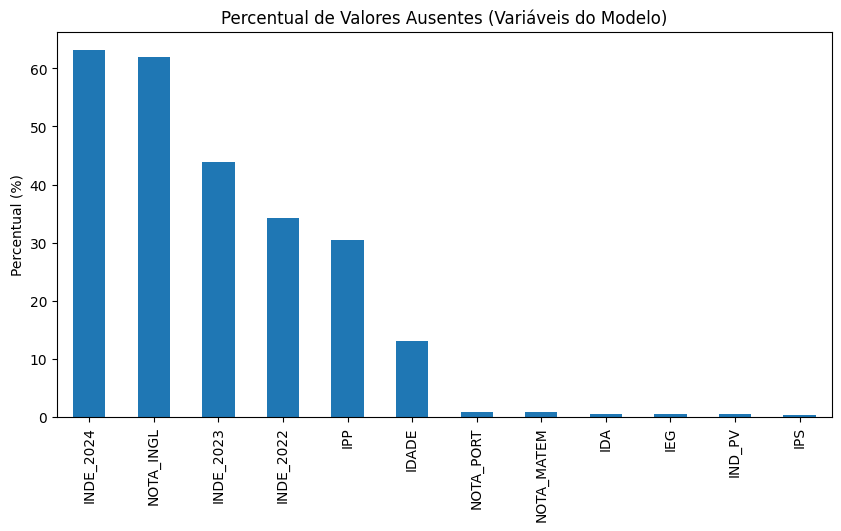

In [180]:
p_nulos2[p_nulos2 > 0].plot(kind="bar", figsize=(10,5))
plt.title("Percentual de Valores Ausentes (Variáveis do Modelo)")
plt.ylabel("Percentual (%)")
plt.show()

#### Criação da variável **INDE_ATUAL**

Olhando as informações históricos da Passos Mágicos temos o indicador INDE calculado por cada ano letivo, distribuído em colunas diferentes (INDE_2022, INDE_2023, INDE_2024). Como a base está estruturada em nível de aluno-ano (um mesmo aluno pode aparecer em anos diferentes), faz mais sentido trabalhar com um único indicador que represente o INDE referente ao ano daquela observação.

Por isso, foi criada a variável INDE_ATUAL, definida da seguinte forma:

* para registros do ano de 2022, INDE_ATUAL = INDE_2022

* para registros de 2023, INDE_ATUAL = INDE_2023

* para registros de 2024, INDE_ATUAL = INDE_2024

Essa transformação traz três diversos benefícios sendo eles:

Coerência temporal: o modelo passa a enxergar, em cada linha, o INDE correspondente ao ano daquela avaliação, respeitando o fato de que um mesmo aluno evolui ao longo do tempo.

Redução de sparsidade (nulos): as colunas originais de INDE por ano apresentavam muitos valores ausentes, já que cada aluno só tem INDE preenchido nos anos em que foi avaliado. Ao consolidar em INDE_ATUAL, concentra-se a informação relevante em uma única variável, reduzindo a proporção de nulos.

Simplicidade para a modelagem: utilizar apenas uma coluna de INDE facilita tanto a etapa de pré-processamento quanto a interpretação dos resultados, mantendo o foco no “estado atual” do aluno naquele ano letivo.

In [181]:
def inde_atual(row):
    if row["ANO"] == 2022:
        return row["INDE_2022"]
    elif row["ANO"] == 2023:
        return row["INDE_2023"]
    elif row["ANO"] == 2024:
        return row["INDE_2024"]
    else:
        return np.nan

df_modelo["INDE_ATUAL"] = df_modelo.apply(inde_atual, axis=1)

# Removendo as colunas com Indicadores antigos do dataset 
df_modelo = df_modelo.drop(columns=["INDE_2022", "INDE_2023", "INDE_2024"], errors="ignore")

A variável NOTA_INGL foi excluída da base de modelagem por apresentar mais de 60% de valores ausentes e por não ser uma disciplina obrigatória em todas as fases. Manter essa variável exigiria imputações e manipulações excessivas, o que poderia introduzir ruído no modelo, além de não representar um componente central na caracterização do risco de defasagem escolar quando comparada a outras notas e indicadores pedagógicos.

In [182]:
df_modelo = df_modelo.drop(columns=["NOTA_INGL"], errors="ignore")

Para tratar os valores ausentes de idade, optou-se por uma estratégia de imputação guiada pelo contexto pedagógico. Em vez de utilizar uma média global, os valores faltantes foram preenchidos com a mediana da idade dos alunos dentro de cada combinação de Fase e Ano da amostra.

In [183]:
if "IDADE" in df_modelo.columns:
    df_modelo["IDADE"] = df_modelo.groupby(["FASE","ANO"])["IDADE"].transform(
        lambda x: x.fillna(x.median())
    )

O indicador IPP (Índice Psicopedagógico) sintetiza a avaliação da equipe de professores, pedagogos e psicopedagogos sobre o desenvolvimento cognitivo, o raciocínio lógico e aspectos comportamentais e emocionais dos estudantes em sua participação no Programa de Aceleração do Conhecimento.

Por seu caráter integrador e por refletir diretamente o desempenho global do aluno, o IPP foi considerado uma variável-chave para a modelagem do risco de defasagem escolar. Mesmo com a ausência desse indicador em 2022, optou-se por mantê-lo na base de modelagem, tratando os valores faltantes de forma cuidadosa em vez de descartar a variável.

In [184]:
# Flag de imputação (0 = valor real observado, 1 = imputado)
df_modelo["IPP_IMPUTADO"] = 0

# registros de 2022 com IPP nulo
na_ipp_2022 = (df_modelo["ANO"] == 2022) & (df_modelo["IPP"].isna())

# Mediana de IPP por FASE usando somente anos com IPP registrado (2023 e 2024)
mediana_ipp_por_fase = (
    df_modelo[df_modelo["ANO"].isin([2023, 2024])]
    .groupby("FASE")["IPP"]
    .median()
)

# Imputar 2022 com mediana da FASE
df_modelo.loc[na_ipp_2022, "IPP"] = (
    df_modelo.loc[na_ipp_2022, "FASE"].map(mediana_ipp_por_fase)
)

# Inclusão da flag
df_modelo.loc[na_ipp_2022, "IPP_IMPUTADO"] = 1

# Se ainda sobrar algum NaN (fase sem mediana, caso raro), imputar com mediana global
if df_modelo["IPP"].isna().any():
    mediana_global = df_modelo["IPP"].median()
    df_modelo["IPP"] = df_modelo["IPP"].fillna(mediana_global)
    df_modelo.loc[df_modelo["IPP"].isna(), "IPP_IMPUTADO"] = 1

In [185]:
df_modelo

,ANO,FASE,IDADE,GENERO,ANO_INGRESSO,INSTITUICAO_ENSINO,IAA,IEG,IPS,IDA,IND_PV,IAN,IPP,NOTA_MATEM,NOTA_PORT,POSSUI_DEFASAGEM,INDE_ATUAL,IPP_IMPUTADO
0,2022,7,19.0,1,2016,1.0,8.300,4.100000,5.6000,4.000000,7.278,5.0,7.5,2.70,3.5,1,5.783,1
1,2022,7,17.0,1,2017,2.0,8.800,5.200000,6.3000,6.800000,6.778,10.0,7.5,6.30,4.5,0,7.055,1
2,2022,7,17.0,1,2016,2.0,0.000,7.900000,5.6000,5.600000,7.556,10.0,7.5,5.80,4.0,0,6.591,1
3,2022,7,17.0,0,2017,2.0,8.800,4.500000,5.6000,5.000000,5.278,10.0,7.5,2.80,3.5,0,5.951,1
4,2022,7,17.0,1,2016,2.0,7.900,8.600000,5.6000,5.200000,7.389,10.0,7.5,7.00,2.9,0,7.427,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,2024,7,15.0,0,2022,3.0,8.751,9.737667,6.2600,6.166667,7.500,10.0,7.5,6.00,6.5,0,7.9319666667333335,0
2924,2024,7,18.0,0,2021,4.0,6.667,9.704333,6.5700,5.483333,7.500,10.0,7.5,6.35,6.3,0,7.611233333266666,0
2925,2024,7,15.0,0,2021,3.0,10.002,9.920000,6.8850,2.633333,7.500,10.0,7.5,0.00,0.0,0,7.449366666666667,0
2926,2024,7,16.0,0,2021,4.0,8.334,9.246000,6.5725,8.266667,7.500,10.0,7.5,8.20,7.8,0,8.243183333333334,0


In [186]:
(df_modelo.isna().mean() * 100).sort_values(ascending=False)

NOTA_PORT             0.732984
NOTA_MATEM            0.698080
INDE_ATUAL            0.698080
IDA                   0.488656
IND_PV                0.453752
IEG                   0.453752
IPS                   0.209424
ANO                   0.000000
FASE                  0.000000
IDADE                 0.000000
IAA                   0.000000
GENERO                0.000000
ANO_INGRESSO          0.000000
INSTITUICAO_ENSINO    0.000000
IPP                   0.000000
IAN                   0.000000
POSSUI_DEFASAGEM      0.000000
IPP_IMPUTADO          0.000000
dtype: float64

Após todas as definições de projeto é possível verificar que chegamos a um valor consideravel de nulos, xxxxxxx

In [187]:
df_modelo_final = df_modelo.copy()

filter_cols = [
    "NOTA_PORT", "NOTA_MATEM", "INDE_ATUAL",
    "IDA", "IND_PV", "IEG", "IPS"
]

for col in filter_cols:
    if col in df_modelo_final.columns:
        df_modelo_final[col] = pd.to_numeric(df_modelo_final[col], errors="coerce")

for col in filter_cols:
    if col in df_modelo_final.columns:
        df_modelo_final[col] = (
            df_modelo_final
            .groupby(["FASE", "ANO"])[col]
            .transform(lambda x: x.fillna(x.median()))
        )

        if df_modelo_final[col].isna().any():
            mediana_global = df_modelo_final[col].median()
            df_modelo_final[col] = df_modelo_final[col].fillna(mediana_global)

# Conferindo se todos os nulos foram devidamente tratados
(df_modelo_final.isna().mean() * 100).sort_values(ascending=False)

ANO                   0.0
FASE                  0.0
IDADE                 0.0
GENERO                0.0
ANO_INGRESSO          0.0
INSTITUICAO_ENSINO    0.0
IAA                   0.0
IEG                   0.0
IPS                   0.0
IDA                   0.0
IND_PV                0.0
IAN                   0.0
IPP                   0.0
NOTA_MATEM            0.0
NOTA_PORT             0.0
POSSUI_DEFASAGEM      0.0
INDE_ATUAL            0.0
IPP_IMPUTADO          0.0
dtype: float64